<a href="https://colab.research.google.com/github/lisapuche/BI_Analyst/blob/main/BI%20Analyst%20test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Business Intelligence Analyst test
## Lisa Puche

## Exploración de los datos

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import pearsonr

In [52]:
bd = pd.read_excel('Business Intelligence Analyst Test (Lisa Puche).xlsx', sheet_name= 'base_de_datos')

#Exploración inicial
bd.head()

,Año,Mes,Solicitadas,Aprobadas,Rechazadas,Abandonadas,Monto Solicitado (USD),Monto Aprobado (USD),Tasa de Interés (%)
0,2021,Enero,500,300,150,50,1000000,600000,5.5
1,2021,Febrero,480,290,140,50,960000,580000,5.4
2,2021,Marzo,450,270,130,50,900000,540000,5.6
3,2021,Abril,470,280,140,50,940000,560000,5.5
4,2021,Mayo,460,275,135,50,920000,550000,5.4


In [69]:
#Exploración inicial
bd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Año                     36 non-null     int64  
 1   Mes                     36 non-null     object 
 2   Solicitadas             36 non-null     int64  
 3   Aprobadas               36 non-null     int64  
 4   Rechazadas              36 non-null     int64  
 5   Abandonadas             36 non-null     int64  
 6   Monto Solicitado (USD)  36 non-null     int64  
 7   Monto Aprobado (USD)    36 non-null     int64  
 8   Tasa de Interés (%)     36 non-null     float64
dtypes: float64(1), int64(7), object(1)
memory usage: 2.7+ KB


In [5]:
#Exploración inicial
bd.describe()

,Año,Solicitadas,Aprobadas,Rechazadas,Abandonadas,Monto Solicitado (USD),Monto Aprobado (USD),Tasa de Interés (%)
count,36.000000,36.000000,36.000000,36.000000,36.000000,3.600000e+01,36.000000,36.000000
mean,2022.000000,516.666667,310.000000,152.777778,53.888889,1.033333e+06,620000.000000,5.625000
std,0.828079,38.396428,22.103652,17.256239,4.646214,7.679286e+04,44207.303857,0.136015
min,2021.000000,440.000000,265.000000,125.000000,50.000000,8.800000e+05,530000.000000,5.400000
25%,2021.000000,490.000000,295.000000,140.000000,50.000000,9.800000e+05,590000.000000,5.500000
50%,2022.000000,515.000000,310.000000,150.000000,50.000000,1.030000e+06,620000.000000,5.600000
75%,2023.000000,542.500000,326.250000,166.250000,60.000000,1.085000e+06,652500.000000,5.700000
max,2023.000000,600.000000,355.000000,190.000000,60.000000,1.200000e+06,710000.000000,5.900000


**Disclaimer: Dado que no hay contextualización de la base, en este punto se asume que los datos corresponden a *solicitudes de crédito* que se registran a través de la plataforma.**

## Análisis de datos

1. Calcula la tasa de aprobación mensual y la tasa promedio de aprobación para cada año. ¿Qué mes y año tuvo la tasa de aprobación más baja y cuál fue esa tasa?

2.	Calcula la tasa de abandono mensual y la tasa promedio de abandono para cada año. ¿Qué patrones observas en la tasa de abandono y qué factores podrían estar contribuyendo a este problema?
3.	Compara los montos solicitados y aprobados mensualmente. ¿Cómo varían los montos solicitados y aprobados a lo largo de los años y qué podría explicar estas variaciones?
4.	Analiza cómo la tasa de interés puede estar afectando las solicitudes y aprobaciones. ¿Existe alguna correlación entre la tasa de interés y la tasa de aprobación o abandono?

In [73]:
#Cálculo de las tasas
bd['Tasa Aprobación'] = bd['Aprobadas'] / bd['Solicitadas']
bd['Tasa Abandono'] = bd['Abandonadas'] / bd['Solicitadas']

### 1. Tasa de aprobación

In [74]:
aprob_tasa_mes = bd.groupby(['Año', 'Mes'])['Tasa Aprobación'].mean()

#Promedio anual
aprob_tasa_año = bd.groupby('Año')['Tasa Aprobación'].mean()

#Valor mínimo de las tasas
tasa_min = aprob_tasa_mes.min()
mes_año_min = aprob_tasa_año.idxmin()

print(f"Tasa de aprobación más baja: {tasa_min:.2%}")
print(f"Año con el promedio de aprobación más bajo: {mes_año_min}")

print(f"\nPromedios anuales:")
aprob_tasa_año

Tasa de aprobación más baja: 59.17%
Año con el promedio de aprobación más bajo: 2023

Promedios anuales:


,Tasa Aprobación
Año,
2021,0.600179
2022,0.601271
2023,0.598948


### 2. Tasa de abandono

In [8]:
aband_tasa_mes = bd.groupby(['Año', 'Mes'])['Tasa Abandono'].mean()

#Promedio anual
aband_tasa_año = bd.groupby('Año')['Tasa Abandono'].mean()

#Valor mínimo de las tasas
tasa_min = aband_tasa_mes.min()
mes_año_min = aband_tasa_año.idxmin()

print(f"Promedios anuales:")
aband_tasa_año

Promedios anuales:


,Tasa Abandono
Año,
2021,0.102300
2022,0.108285
2023,0.104046


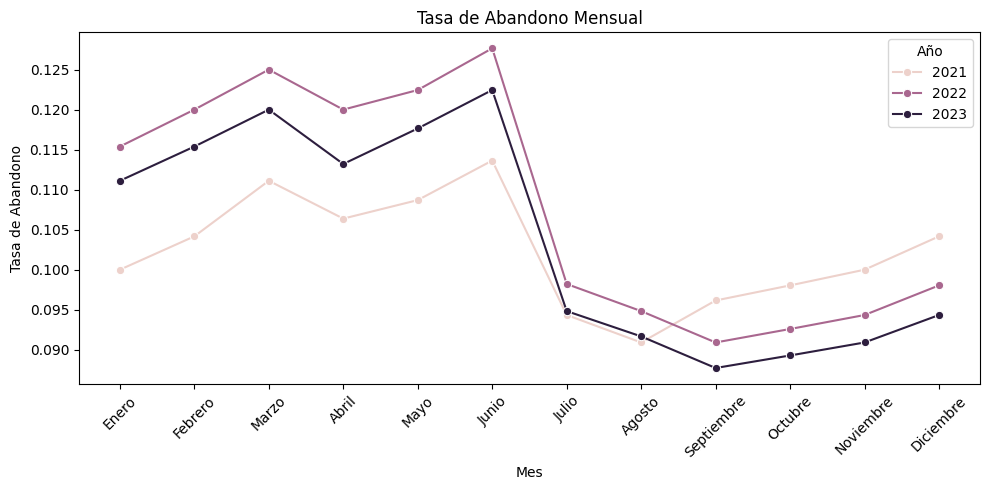

In [35]:
#Tasa de abandono mensual
aband_tasa_mes = aband_tasa_mes.reset_index()
aband_tasa_mes['Mes'] = pd.Categorical(aband_tasa_mes['Mes'], categories=['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'], ordered=True)
aband_tasa_mes = aband_tasa_mes.sort_values(['Año', 'Mes'])

plt.figure(figsize=(10, 5))
sns.lineplot(x='Mes', y='Tasa Abandono', hue='Año', data=aband_tasa_mes, marker= 'o')
plt.title('Tasa de Abandono Mensual')
plt.xlabel('Mes')
plt.ylabel('Tasa de Abandono')
plt.xticks(rotation=45)
plt.legend(title='Año')
plt.tight_layout()
plt.show()


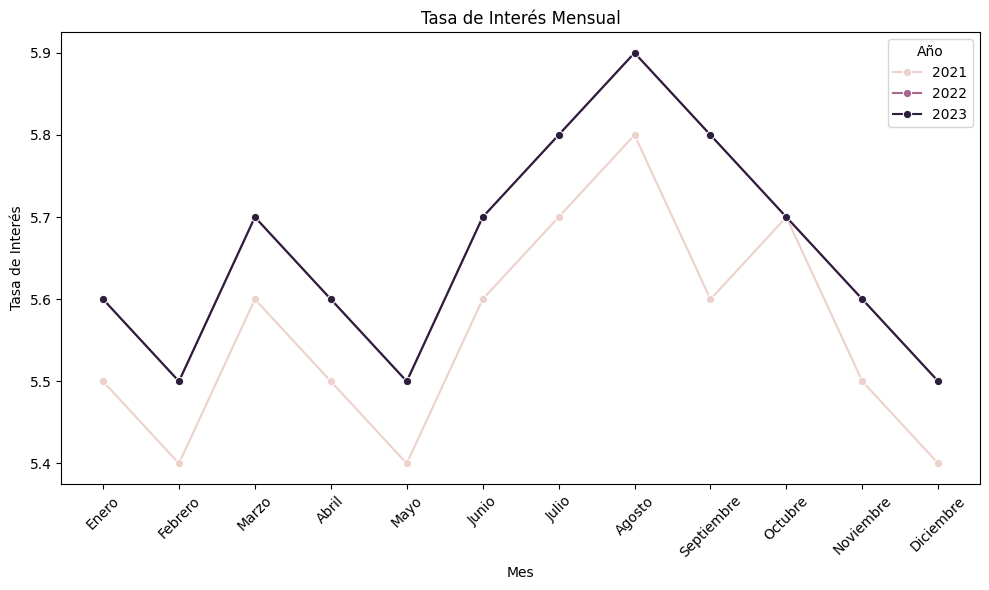

In [47]:
#Tasa de interés mensual

plt.figure(figsize=(10, 6))
sns.lineplot(x='Mes', y='Tasa de Interés (%)', hue='Año', data=bd, marker='o')
plt.title('Tasa de Interés Mensual')
plt.xlabel('Mes')
plt.ylabel('Tasa de Interés')
plt.xticks(rotation=45)
plt.legend(title='Año')
plt.tight_layout()
plt.show()


**La tasa de abandono representa el porcentaje de solicitudes iniciadas por los usuarios que no se completan.**

Se observa que la mayor tasa de abandono durante los periodos registrados se da en el mes de junio para cada año. Esto puede deberse a varios factores:

1. Cierre de semestre: las personas están buscando créditos y exploran y evalúan varias posibilidades.
2. Falta de seguimiento al usuario: al evaluar varias posibilidades, el usuario puede olvidarse de la solicitud y si no hay un sistema se seguimeinto activo, esta solicitud no se completará.
3. Miedo al endeudamiento: si bien la tasa de interés de junio no es la más alta, puede causar que algunos usuarios desistan de la solicitud del crédito.

Es interesante observar que en agosto, mes que tradicionalmente presenta mayores tasas de interés, la tasa de abandono es significativamente más baja.

Sin embargo, en febrero, mayo y diciembre suele haber una tasa muy baja de abandonos. Algunos factores que explican esto son el inicio de año con metas de inversión claras y el cierre de año y de decisiones financieras.

También es notoria la evolución de la tasa de abandono a través de los años, siendo el año 2023 el que tiene una menor tasa. Posiblemente gracias a la mejora en las operaciones y la optimización de la plataforma.



## 3. Montos solicitados y aprobados

In [57]:
bd_melt = bd.melt(id_vars=['Año', 'Mes'],
                   value_vars=['Solicitadas', 'Aprobadas'],
                   var_name='Tipo', value_name='Monto')


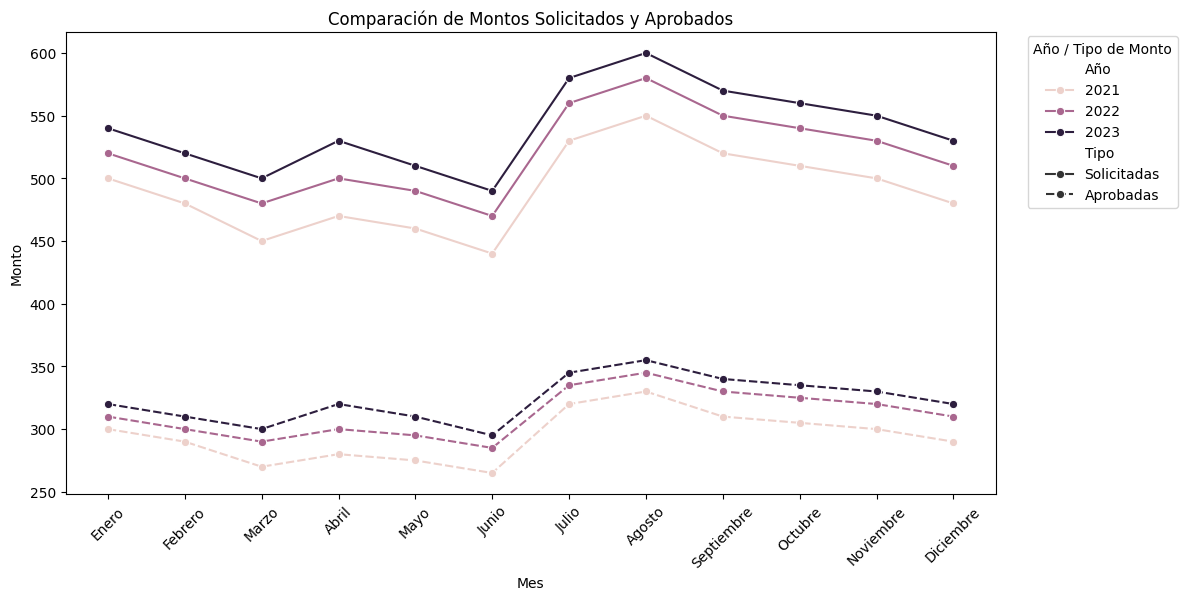

In [66]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Mes', y='Monto', hue='Año', style='Tipo', data=bd_melt, marker='o')

plt.title('Comparación de Montos Solicitados y Aprobados')
plt.xlabel('Mes')
plt.ylabel('Monto')
plt.xticks(rotation=45)
plt.legend(title='Año / Tipo de Monto',
           loc='upper left',
           bbox_to_anchor=(1.03, 1),
           borderaxespad=0.3,
           handlelength=2,
           frameon=True)
plt.show()


Dentro de las principales observaciones, se tiene que:

1. Año tras año, los montos socilitados tienden a subir.
2. Tanto los montos solicitados como aprobados aumentan significativamente en el tercer trimestre y el comportamiento es consistente en los tres años.
3. La diferencia entre lo solicitado y lo aprobado es relativamente estable, lo que indica el sistema de aprobación es consistente, y las tendencias de abandono están más relacionadas con la **decisión del usuario** que con políticas internas.

Lo que podría explicar estas variaciones podría ser:

1. Mayor cantidad de gastos a mitad de año, generando mayor necesidad de financiamiento.
2. Las primas semestrales aumentan la disponibilidad de liquidez de cada persona.
3. Por el contrario, los inicios de años pueden ser meses de baja liquidez y por ende, de solicitudes más bajas.


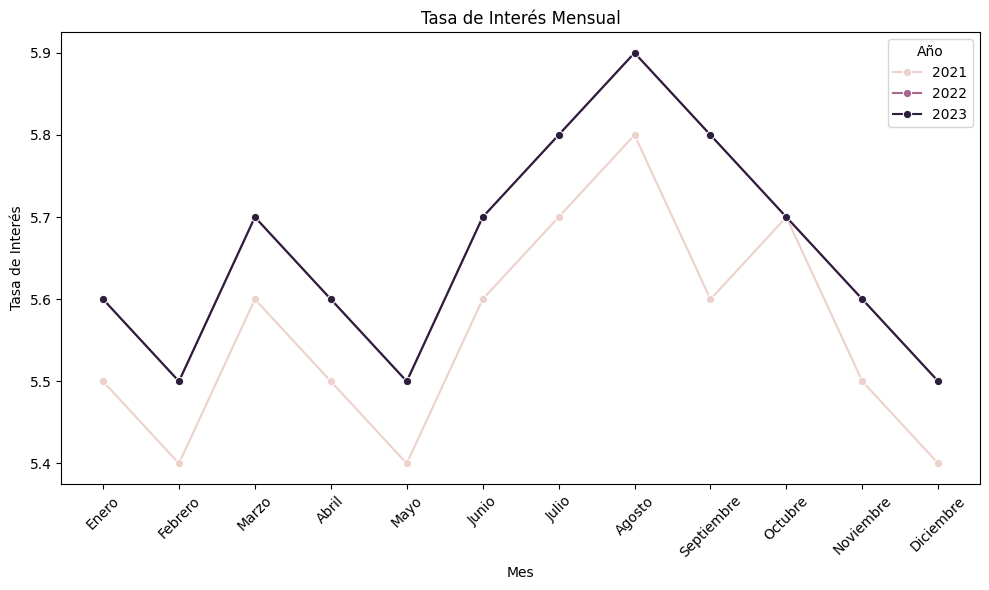

In [68]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Mes', y='Tasa de Interés (%)', hue='Año', data=bd, marker='o')
plt.title('Tasa de Interés Mensual')
plt.xlabel('Mes')
plt.ylabel('Tasa de Interés')
plt.xticks(rotation=45)
plt.legend(title='Año')
plt.tight_layout()
plt.show()

In [75]:
#Correlación con tasa de aprobación
corr_apr, pval_apr = pearsonr(bd['Tasa de Interés (%)'], bd['Tasa Aprobación'])

#Correlación con tasa de abandono
corr_abn, pval_abn = pearsonr(bd['Tasa de Interés (%)'], bd['Tasa Abandono'])

print(f"Correlación con Tasa de Aprobación: {corr_apr:.4f} (p-valor: {pval_apr:.4f})")
print(f"Correlación con Tasa de Abandono:   {corr_abn:.4f} (p-valor: {pval_abn:.4f})")

Correlación con Tasa de Aprobación: -0.3892 (p-valor: 0.0190)
Correlación con Tasa de Abandono:   -0.3449 (p-valor: 0.0394)


De acuerdo con el cálculo de las correlaciones, estos resultados son estadísticamente significativos, lo que permite hacer inferencias sobre ellos.  

Por un lado, a medida que la tasa de interés aumenta, la tasa de aprobación tiende a disminuir. Así, cuando los créditos son más caros, menos personas terminan siendo aprobadas.

Por otro lado, cuando la tasa de interés sube, la tasa de abandono también tiende a disminuir. Entonces, cuando las tasas están más altas, solo aquellos usuarios decididos se animan a solicitar un crédito, traduciéndose a menos abandonos.



## Dashboard

(Adjunto Power BI)

## Recomendaciones

### 1. ¿Qué cambios propondrías en el proceso para aumentar la tasa de aprobación?

Para aumentar la tasa, se debe mejorar el flujo del usuario: desde la solicitud hasta la notificación clara del rechazo. Para ello, considero que:

1. Se debe optimizar la filtración desde el inicio, implementando preguntas breves pero significativas para la viabilidad de los créditos, según los perfiles.
2. Creación de un Simulador que permita evaluar al usuario de una forma más dinámica.
3. Transparencia en los requisitos de aprobación y de las razones por las que algunos usuarios no tienen el perfil adecuado.

Muchas veces, el mismo usuario no conoce las condiciones para ser aprobado y puede llevarlo a hacer un trámite que claramente no aprobará.
4. Feedback detallado y propuestas de mejora personalizadas para el usuario.






### 2. ¿Qué medidas podría tomar la empresa para mantener a los solicitantes comprometidos durante todo el proceso?

El usuario actual prefiere la rapidez, la simplicidad y la facilidad. Es importante que el proceso se adapte a sus necesidades.

1. El diseño de una solicitud corta, intutitiva y amigable es fundamental. En este caso, se podría implementar una barra de progreso (apuntando a la rapidez) y un sistema de guardado automático en caso de tener problemas de conexión, para que su progreso no se reinicie (apuntando a la simplicidad y facilidad).

2. Mensajes que mantengan la retención del usuario a medida que completa cada paso de la solicitud.

3. Recordatorios automatizados para el usuario y seguimiento activo.

4. Asegurar la urgencia y aumentar el valor percibido a través de ofertas o beneficios al completar el proceso.

### 3. ¿Qué segmentos del mercado podrían ser explorados para expandir la cuota de mercado de la empresa? teniendo en cuenta la información publicada en la web de Jelou

Basándose en sus capacidades actuales y con el objetivo de diversificar su oferta y fortalecer su presencia en el mercado, Jelou podría expandir su cuota de mercado hacia:

1. Gobiernos y entidades públicas. La inversión destinada a transformación digital es un auge en el sector público porque permite la automatización de procesos para la ciudadanía.
2. Sector automotriz. Es un sector que está adaptando soluciones tecnológicas rápidamente para mejorar la experiencia del cliente.
3. Alianzas con operadores móviles para mejorar su atención al usuario.



## Técnico

### 1. Si te entregaran una base de datos con miles de registros de clientes, ¿cuál sería tu primer paso para comenzar un análisis?

Inicialmente es fundamental conocer la base: qué tipo de datos maneja, cuáles son las variables, cuál es la contextualización de los datos de esos clientes, si existen datos nulos o datos atípicos.

Una vez conocido se deben convertir los datos a una forma más manejable. Convertir a numéricos o texto si es necesario de acuerdo con el tipo de variable, imputar datos nulos para poder trabajar con ellos y entender los datos atípicos.

También, es importante identificar patrones y comprender las variables para tener en cuenta los análisis que se pueden hacer con esos datos.

### 2. ¿Qué métricas incluirías en un dashboard para ventas, marketing y retención?

En este tipo de dashboards es importante proporcionar una visualización del embudo de conversión del usuario. Las métricas que incluiría estarían asociadas con la eficiencia del proceso, la efectividad de campañas y la retención del usuario.

1. Total de ventas, número de transacciones, % de leads que terminan en una venta, tiempo promedio desde el contacto hasta el cierre, crecimiento de las ventas, ingresos o captaciones por plataforma.

2. Leads generados, costo por lead, ROI de campañas, CTR en las diferentes plataformas, % de abandono del proceso.

3. Tasa de retención y tasa de deserción, tiempo promedio de permanencia en el proceso, ingreso que genera el cliente para la empresa, feedback de abandono.

### 3. ¿Cómo abordas un problema cuando no tienes todos los datos disponibles? ¿Qué haces en ese caso?

En este caso, es pertinente entender cuál es el objetivo del análisis de estos datos y qué preguntas se deben responder. Se tienen dos opciones:

1. Imputar valores nulos y seleccionar el método de imputación de acuerdo con el comportamiento de los datos existentes.

2. Descartar el dato solo si se considera que no es relevante para el análisis, con previa validación del responsable.

### 4. ¿Qué herramientas o técnicas usarías para detectar patrones o anomalías en un conjunto de datos?

Realizar un EDA es importante antes de cualquier análisis ya que en este se detectan aquellos valores atípicos, comportaminto en los datos y tendencias que en un análisis posterior son de utilidad.

Dependiendo de los datos realizaría: desviaciones de datos, gráficos de dispersión, correlaciones, histogramas, clusterización.

### 5. Si tuvieras que definir un conjunto de métricas para hacer seguimiento semanal a un equipo, ¿qué lógica seguirías para escogerlas?

Inicialmente, definiría cuál es el objetivo al que debe apuntar el equipo. Una vez definido, generaría una lluvia de ideas de resultados que quisiera ver a lo largo del mes y que se evaluarían semanalmente.

Después, traduciría esas ideas en dimensiones evaluables que sean fáciles de calcular, interpretar y comparar con un histórico.

Por último, me parece clave que dada la finalización del seguimiento, el equipo tenga claridad sobre su desempeño, por qué tienen esos resultados, qué hace falta para mejorar y reconocer su progreso.

Todo esto podría visualizarse a través de un dashboard de seguimiento.